In [1]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
    return

from analysis_thinshell import *
from plotting_functions import *
from peak_modeling import *
from flux_modeling import *
plt.close('all')

import matplotlib
matplotlib.rcParams["savefig.directory"] = GAMMA_dir + "/bin/Tools/figures"
import matplotlib.pyplot as plt
plt.ion()
%matplotlib ipympl


In [2]:
T_label  = "$\\tilde{T}$"
nu_label = "$\\nu/\\nu_0$"
nF_label = "$\\nu F_\\nu / \\nu_0 F_0$"

In [3]:
def logau_to_key(log_au):
  key = 'sweep_' + f"log_au={log_au:.1f}"
  return key

def check_done_logau():
  folders = glob.glob(GAMMA_dir + "/results/sweep_log_au=*")
  done_logau = np.array(sorted([float(f.split("=")[1]) for f in folders]))
  return done_logau

96


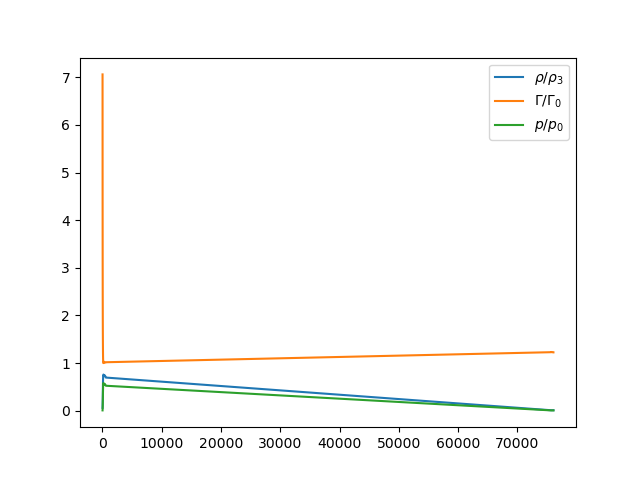

In [9]:
log_au = 1.2
key = 'sweep_' + f"log_au={log_au:.1f}"
env = MyEnv(key)
data = open_rundata(key, 4)
print(len(data))
#d_fit = cellsBehindShock_fromData(data)
try:
  popts = get_hydrofits_shell_new(data)
except RuntimeError:
  plt.figure()
  plt.plot(data.rho/env.rho3_sc, label='$\\rho/\\rho_3$')
  lfac = derive_Lorentz(data.vx)
  plt.plot(lfac/env.lfac0, label='$\\Gamma/\\Gamma_0$')
  plt.plot(data.p/env.p_shsc, label='$p/p_0$')
  plt.legend()

#popt_lfac, popt_ShSt, _, popt_nu, popt_L = get_hydrofits_shell_new(data)
#print(popt_lfac, popt_ShSt, popt_nu, popt_L)

In [8]:
val = get_variable(data, 'lfac', env)/env.lfac0
print(len(val), len(data))

96 96


In [7]:
def plot_earlydata(name, normName='', key='Last', z=4, xvar='x', imax=None):
  fig, ax = plt.subplots()
  data = open_rundata(key, z)
  fit = cellsBehindShock_fromData(data)
  if xvar == 'x':
    x = data.x.to_numpy() * c_ /env.R0
    xlabel = '$R/R_0$'
  elif xvar == 'it':
    x = data.index
    xlabel = 'it'
  if imax is not None:
    index = data.index
    xmax = x[index<=imax][-1]
  else:
    xmax = x[-1]
  val = get_variable(data, name, env)
  if normName:
    norm = getattr(env, normName)
    val /= norm
    ax.axhline(1., c='k', ls=':', lw=.9)
  ax.plot(x[x<=xmax], val[x<=xmax])
  ax.set_xlabel(xlabel)
  ax.set_title(name)

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

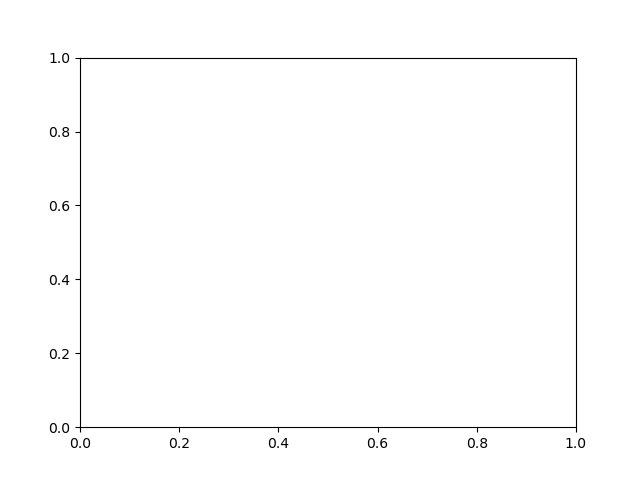

In [8]:
key = logau_to_key(1.2)
plot_earlydata('lfac', key=key, z=4, xvar='it')

Goal: test validity of a fit. Method:
- grab hydro data
- plot fits hydro ($\Gamma$, $\Gamma_{ud}-1$, $\nu'_m$, $L'_{\rm bol}$) vs raw data
- plot fit peaks vs calculated + extracted from hydro data

In [17]:
dfvars = {'lfac': 'lfac', 'ShSt': 'ShSt', 'nu': 'nup_m2', 'L': 'Lbol'}
def get_norms(env, z):
    z_norms = {
        1: {'lfac': env.lfac0, 'ShSt': env.lfac21-1, 'nu': env.nu0pFS, 'L': env.LbolpFS},
        4: {'lfac': env.lfac0, 'ShSt': env.lfac34-1, 'nu': env.nu0p,   'L': env.Lbolp  },
    }
    return z_norms[z]

In [18]:
def savgol_smooth(array, window=7, polyorder=3):
  window = max(window, polyorder + 2)  # savgol constraint
  if window % 2 == 0:
    window += 1  # savgol requires odd window
  out = savgol_filter(array, window, polyorder)
  return out

Compare raw hydro data with the corresponding fit

In [19]:
def get_effective_asympt(x_inf, alpha, s):
  s_eff = np.sign(-alpha)*np.abs(s)
  a_eff = alpha * (1 - x_inf**s_eff)
  x_break = x_inf ** (1. / a_eff)
  return a_eff, x_break

def plot_fit_hydro(log_au, z, varname, 
    ax_in=None, fullrescale=False, withbreak=False, xvar='x', **kwargs):
  '''
  Plot the fit vs data for one of the hydro var
  '''
  fitfuncs = (smooth_bpl_apy, smooth_bpl0_apy)

  if ax_in is not None:
    ax = ax_in
  else:
    fig, ax = plt.subplots()


  key = 'sweep_' + f"log_au={log_au:.1f}"
  env = MyEnv(key)
  data = open_rundata(key, z)
  x_d = data.x.to_numpy() * c_ / env.R0
  norms = get_norms(env, z)
  if varname not in norms:
    print("Variable 'varname' must be in", list(norms))
    return 0.
  mult = x_d if varname == 'nu' else 1.
  y = get_variable(data, dfvars[varname], env) * mult / norms[varname]
  noBeta = True # if varname=='lfac' else False
  popt = get_fitting_smoothBPL_v2(x_d, y,
    noBeta=noBeta, fitfuncs=fitfuncs)

  # smooth data to see a bit better what's going on
  # same smoothing as in the fitting method
  y = savgol_filter(y, 7, 3)

  if noBeta:
    func = fitfuncs[1]
  else:
    func = fitfuncs[0]
  fit = func(x_d, *popt)
  
  x = data.index.astype(int) if xvar == 'it' else x_d
  fitcolor = 'k'
  if (ax_in is not None) and ('c' in kwargs):
    fitcolor = kwargs.get('c')
  
  if fullrescale:
    scale = func(1., *popt)
    # force y(0)=1
    y /= scale
    fit /= scale
  line, = ax.loglog(x, y, **kwargs)
  ax.loglog(x, fit, ls='--', c=fitcolor, lw=.9)

  if ax_in is None:
    ax.set_title(varname)
    create_legend_colors(ax, ['data', 'fit'], ['C0', 'k'])

def compare_fits_hydro(logau_arr, z, varname, fullrescale=True):
  fig, ax = plt.subplots()
  N = len(logau_arr)
  cmap = plt.cm.jet
  norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
  colors = cmap(norm(logau_arr))
  names = []
  for i, logau in enumerate(logau_arr):
    plot_fit_hydro(logau, z, varname, ax_in=ax, fullrescale=fullrescale, c=colors[i])
    names.append(f'{logau:.1f}')

  leg_st = create_legend_styles(ax, ['data', 'fit'], ['-', '--'], loc='lower right')
  if N < 5:
    create_legend_colors(ax, names, colors, title='log$_{10}(a_u - 1)$', loc='lower center')
    ax.add_artist(leg_st)
  else:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label='log$_{10}(a_u - 1)$')

def compare_breaks(log_au, z):
  fig, ax = plt.subplots()
  for varname in ['lfac', 'ShSt', 'nu', 'L']:
    plot_fit_hydro(log_au, z, varname, ax_in=ax, withbreak=True)
        #withbreak=(True if varname == 'lfac' else False))

In [20]:
#plot_fit_hydro(0.5, 1, 'ShSt', xvar='it')

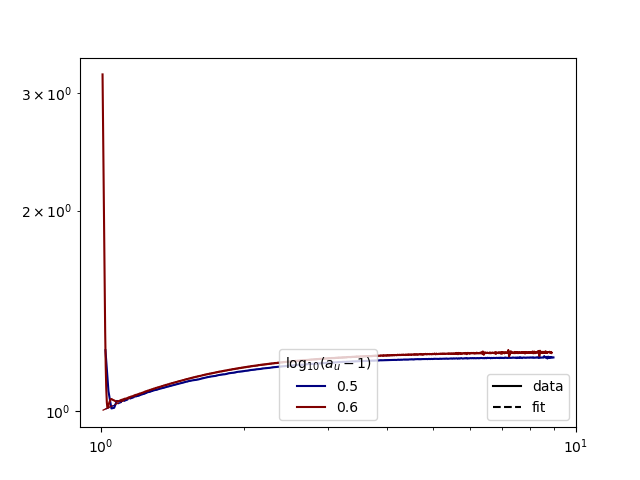

In [21]:
done_logau = check_done_logau()
logau_arr = [0.5, 0.6]
compare_fits_hydro(logau_arr, 4, 'lfac')

In [ ]:
%%skip
varname = 'nu'
logau_arr = np.arange(-0.6, 0.6, 0.1)
logau_arr[np.abs(logau_arr)<1e-2] = 0
compare_fits_hydro(logau_arr, 1, varname)
plt.xlabel('$x=R/R_0$')
plt.title('Variable ' + varname + ', rescaled')
plt.tight_layout()

Grab the fitting parameters and compare them among each other

In [23]:
def a_from_popt(popt, norm=None):
  A, x_b, alpha, s = popt
  a = - alpha * (1 + x_b**(-1/s))
  return a

def yinf_from_popt(popt, norm=None):
  A, x_b, alpha, s = popt
  yinf = A * 2**(-alpha*s)
  if norm is not None:
    yinf /= norm
  return yinf


def get_fits_values(varname, param, log_au=0, z=4):
  '''Return fitting parameter param of variable varname'''
  varnames = ['lfac', 'ShSt', 'nu', 'L']
  params = ['A', 'x_b', 'alpha', 'beta', 's']
  derived = ['a', 'y_inf']
  der_funcs = [a_from_popt, yinf_from_popt]
  popt, env = get_fit(varname, log_au, z)
  i = 0
  noBeta = True # if varname=='lfac' else False
  if noBeta:
    del params[params.index('beta')]
  if param in params:
    i = params.index(param)
    out = popt[i]
  elif param in derived:
    i = derived.index(param)
    out = der_funcs[i](popt)
  else:
    print("Variable 'param' must be in ", params)
    return 0.
  return out

def get_fit(varname, log_au=0, z=4):
  varnames = ['lfac', 'ShSt', 'nu', 'L']
  key = 'sweep_' + f"log_au={log_au:.1f}"
  env = MyEnv(key)
  data = open_rundata(key, z)
  norms = get_norms(env, z)
  x = data.x.to_numpy() * c_ / env.R0
  mult = x if varname == 'nu' else 1.
  if varname not in norms:
    print("Variable 'varname' must be in", list(norms))
    return 0.
  y = get_variable(data, dfvars[varname], env) * mult / norms[varname]
  noBeta = True # if varname == 'lfac' else False
  popt = get_fitting_smoothBPL_v2(x, y, noBeta=noBeta)
  return popt, env

def plot_fits_values(logau_arr, varname, param, z=4, ax_in=None, **kwargs):
  if ax_in is not None:
    ax = ax_in
  else:
    fig, ax = plt.subplots()
  vals = []
  for log_au in logau_arr:
    val = get_fits_values(varname, param, log_au, z)
    vals.append(val)
  ax.scatter(logau_arr, vals, marker='x', **kwargs)
  if ax_in is None:
    prefix = '\\' if param in ['alpha', 'beta'] else ''
    title = f'${prefix+param}$ from fitting {varname}'
    ax.set_xlabel('log$_{10}(a_u-1)$')
    ax.set_.title(title)
  
def compare_fits(logau_arr, varnames, param, z=4):
  fig, ax = plt.subplots()
  #colors = plt.cm.jet(np.linspace(0,1,len(varnames)))
  colors = ['C0', 'C1', 'C2', 'C3']
  for i, name in enumerate(varnames):
    plot_fits_values(logau_arr, name, param, z=z, ax_in=ax)#, color=colors[i])
  
  create_legend_colors(ax, varnames, colors)
  ax.set_xlabel('log$_{10}(a_u - 1)$')
  name = 'y_\\infty' if param == 'y_inf' else param
  prefix = '\\' if name in ['alpha', 'beta'] else ''
  params = ['A', 'x_b', 'alpha', 'beta', 's']
  head = 'Fitting parameter ' if name in params else 'Physical quantity '
  ax.set_title(head + f'${prefix+name}$')


In [ ]:
%%skip
x = np.linspace(0,20)
y0 = 10 * x / (1+x)
def y(s):
  return (x**-s + 10**-s)**(-1/s)
plt.figure()
plt.plot(x, y0, label='1/x')
for s in range(1, 10,2):
  plt.plot(x, y(s), label=f's = {s}')
plt.legend()

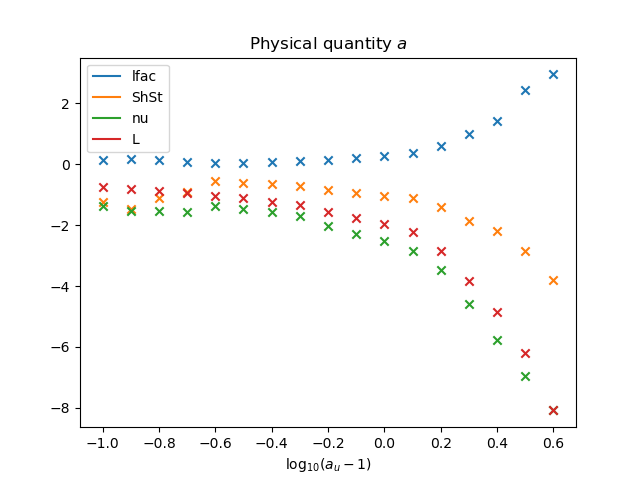

In [24]:
logau_arr = done_logau
#compare_fits(logau_arr, ['ShSt', 'nu', 'L'], 'beta', z=4)
compare_fits(logau_arr, ['lfac', 'ShSt', 'nu', 'L'], 'a', z=4)

Compare peaks with the corresponding fit

- plot comparing peaks from data to peaks from fit
- try fitting a sim with a 'random' $a_u$ to find what's missing
- write what's missing

In [ ]:
def get_peaks_data(key, z, Tmax=20):
  env = MyEnv(key)
  N = getattr(env, f'Nsh{z}')
  nuobs, Tobs, env = obs_arrays_peakcentred(key, Tmax=Tmax, NT=2*N)
  data = open_rundata(key, z)
  t_max = data.iloc[-1].t
  fastshell = (data.iloc[0].trac < 1.5)
  front = 'RS' if fastshell else 'FS'
  g = getattr(env, 'g'+front)
  g2 = g*g

  #popt_lfac, popt_ShSt, _, popt_nu, popt_L = get_hydrofits_shell_new(data)
  #d_fit = cellsBehindShock_fromFit(key, popt_lfac, popt_ShSt, t_max, fastshell=fastshell)
  d_fit = cellsBehindShock_fromData(data)
  nF = run_nuFnu_vFC(d_fit, nuobs, Tobs, env)
  tnu = normalize_freq(nuobs, z, env)
  nupk_data, nFpk_data = extract_peaks(tnu, nF)
  return nupk_data, nFpk_data

def get_model_params(key, z):
  '''
  Parameters for peaks_model_C25
  '''
  env = MyEnv(key)
  reverse = False if z==1 else True
  data = open_rundata(key, z)
  popt_lfac, popt_ShSt, _, popt_nu, popt_L = get_hydrofits_shell_new(data)
  t_max = data.iloc[-1].t
  d_fit = cellsBehindShock_fromFit(key, popt_lfac, popt_ShSt, t_max, fastshell=reverse)
  dR = d_fit.iloc[-1].x * c_ /env.R0 - 1
  au = env.a_u
  return au, dR, reverse

def construct_peaks_model(key, z, Tmax=20):
  env = MyEnv(key)
  N = getattr(env, f'Nsh{z}')
  nuobs, Tobs, env = obs_arrays_peakcentred(key, Tmax=Tmax, NT=2*N)
  T = normalize_time(Tobs, z, env)
  data = open_rundata(key, z)
  g2 = env.gFS**2 if z==1 else env.gRS**2
  Tf, t_max, popt_lfac, popt_ShSt, popt_nu, popt_L, popt_xi = get_anglefits(data, Tmax=Tmax, returnAll=True)
  nupk, nFpk = peaks_fromfits(T, Tf, g2, popt_lfac, popt_nu, popt_L, popt_xi)
  print(popt_xi)
  return nupk, nFpk

def compare_model_data(key, z, Tmax=20, direct=True):
  '''
  Compare data with the emission model using the parameters from data
  '''
  env = MyEnv(key)
  N = getattr(env, f'Nsh{z}')
  col = 'b' if z==1 else 'r'
  nuobs, Tobs, env = obs_arrays_peakcentred(key, Tmax=Tmax, NT=2*N)
  T = normalize_time(Tobs, z, env)
  au, dR, reverse = get_model_params(key, z)
  if direct:
    nu_mod, nF_mod = construct_peaks_model(key, z, Tmax)
  else:
    nu_mod, nF_mod = peaks_model_C25(T, au, dR, reverse)
  nu_dat, nF_dat = get_peaks_data(key, z, Tmax=Tmax)
  # nu_dat = savgol_smooth(nu_dat)
  # nF_dat = savgol_smooth(nF_dat)

  fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True)
  ax0.semilogy(T, nu_dat, c=col, label='data')
  ax0.semilogy(T, nu_mod, ls='--', c='k', label='model')
  ax1.plot(T, nF_dat, c=col)
  ax1.plot(T, nF_mod, ls='--', c='k')

  ax0.set_title(f'$a_u = {au:.1f}$, $\\Delta R/R_0 = {dR:.2f}$')
  ax1.set_xlabel(T_label)
  ax0.set_ylabel(nu_label)
  ax1.set_ylabel(nF_label)
  fig.legend()
  fig.tight_layout()


In [ ]:

log_au = 0
z = 4
key = 'sweep_' + f"log_au={log_au:.1f}"
compare_model_data(key, z)

In [ ]:
%%skip
log_au = 0
z = 1
key = 'sweep_' + f"log_au={log_au:.1f}"
compare_model_data(key, z)

In [ ]:
def plot_fit_angle(name, z=4):
  key = 'xi_' + name
  subs = ['k', 'A', 'x_b', 's']
  names = ['xi_' + s for s in subs]
  A0 = 6*2**(-2)
  bounds = {'k':(1e-4, 1.), 'A':(A0*0.01, A0*100.), 
    'x_b':(1e-3, 100), 's':(1e-3, 3)}
  if name not in subs:
    print("Variable 'name' must be in ", subs)
    return 0.
  

  front = 'FS' if z==1 else 'RS'
  df = open_sweep(front)
  print(key)
  x = df.log_aum.to_numpy()
  y = df[key].to_numpy()
  # x_ = np.linspace(x.min(), x.max(), 100)
  # y_ = 
  
  plt.figure()
  plt.plot(x, y)
  for b in bounds[name]:
    plt.axhline(b, ls=':', c='k')

def plot_ximax(t, params, ax_in=None, **kwargs):
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
  A, x_b, s = params
  y = smooth_bpl_apy(t, A, x_b, -1, 0, s)
  ax.plot(t, y)
  ax.set_xlabel('$g^2\\bar{T}$')
  ax.set_ylabel('$\\xi_{\\max}$')

def compare_xis(front):
  fig, ax = plt.subplots()

  df = open_sweep(front)
  logau_arr = df['log_aum'].to_numpy()
  N = len(logau_arr)
  cmap = plt.cm.jet
  norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
  colors = cmap(norm(logau_arr))
  sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
  fig.colorbar(sm, ax=ax, label='log$_{10}(a_u - 1)$')
  params_arr = df[['xi_A', 'xi_x_b', 'xi_s']].to_numpy()
  T = np.linspace(0, 20, 500)
  for log_au, params, col in zip(au_arr, params_arr, colors):
    au = 1 + 10**log_au
    g2 = g2_from_au(au)[0 if front == 'FS' else 1]
    t = g2*T  # T is bar{T} = tilde{T}-1 here
    plot_ximax(t, params, ax_in=ax, c=col)


In [ ]:
def fit_peaks_for_au(T, nupk_data, nFpk_data, reverse=True):
  '''
  Take peak data and try to find corresponding a_u and Delta R/R0
  '''

  # params : a_u, DeltaR/R0
  def residuals(params, T, nupk_data, nFpk_data):
    nupk_model_fit, nFpk_model_fit = peaks_model_C25(T, *params, reverse=reverse)
    r1 = nupk_model_fit - nupk_data
    r2 = nFpk_model_fit - nFpk_data  
    return np.concatenate([r1, r2])
  # priors
  # -> prior and bounds on dR could be obtained by peak finding
  p0 = [3., 1.5]
  bounds = ([1.3, 0.1], [4.2, 10.])
  res = least_squares(residuals, p0, bounds=bounds,
    args=(T, nupk_data, nFpk_data))
  popt = res.x
  return popt


def test_fitting(key, z, fit=True):
  dfile_path, dfile_bool = get_runfile(key, z)
  if not dfile_bool:
    extract_data_thinshell(key, cells=[1, 4], noOut=True)
  env = MyEnv(key)
  N = getattr(env, f'Nsh{z}')
  nuobs, Tobs, env = obs_arrays_peakcentred(key, Tmax=10, NT=2*N)
  T = normalize_time(Tobs, z, env)
  nupk_data, nFpk_data = get_peaks_data(key, z, Tmax=10)
  reverse = False if z==1 else True
  col = 'b' if z==1 else 'r'
  data = open_rundata(key, z)
  data_fit = cellsBehindShock_fromData(data)
  dR = (data_fit.iloc[-1].x * c_ / env.R0) - 1.
  nupk_model_sim, nFpk_model_sim = peaks_model_C25(T, env.a_u, dR, reverse=reverse)
  fig, (ax0, ax1) = plt.subplots(2, 1)
  ax0.semilogy(T, nupk_data, c=col, label=f'simulation')
  mod_label = f'sim: ({env.a_u:.2f}, {dR:.2f})' if fit else 'model'
  ax0.semilogy(T, nupk_model_sim, ls='--', c='k', label=mod_label)
  ax1.plot(T, nFpk_data, c=col)
  ax1.plot(T, nFpk_model_sim, ls='--', c='k')
  legtitle = ''
  if fit:
    popt = fit_peaks_for_au(T, nupk_data, nFpk_data, reverse)
    nupk_model_fit, nFpk_model_fit = peaks_model_C25(T, *popt, reverse=reverse)
    print(f'Initial params: au = {env.a_u:.2f}, dR/R0 = {dR:.2f}')
    print(f'Found from fit: au = {popt[0]:.2f}, dR/R0 = {popt[1]:.2f}')
    ax0.semilogy(T, nupk_model_fit, ls=':', c='k', label=f'best fit: ({popt[0]:.2f}, {popt[1]:.2f})')
    ax1.plot(T, nFpk_model_fit, ls=':', c='k')
    legtitle = '$(a_u, \\Delta R/R_0)$'

  fig.legend(title=legtitle)
  ax1.set_xlabel(T_label)
  ax0.set_ylabel(nu_label)
  ax1.set_ylabel(nF_label)
  fig.tight_layout()


In [ ]:
%%skip
key, z = 'Last', 4
test_fitting(key, z, fit=False)
# it works for a_u!, both RS and FS independantly

In [ ]:
%%skip
key, z = 'Last', 1
test_fitting(key, z)

In [ ]:
def get_flux_data(Tobs, nuobs, key):
  '''
  Get the observed flux (normalized to F0,RS)
  '''
  env = MyEnv(key)
  nF_tot = np.zeros((len(Tobs), len(nuobs)))
  for z in [4, 1]:
    data = open_rundata(key, z)
    if type(data) == bool:
      analyze_run(key, savefile=True, noOut=True)
      data = open_rundata(key, z)
    fit = cellsBehindShock_fromData(data)
    nF = run_nuFnu_vFC(fit, nuobs, Tobs, env, norm=False)
    #F = nF/nuobs
    nF_tot += nF
  return nF_tot

def fit_flux(T, nu, nF_data):
  '''
  Fit flux as contribution from two fronts
  all inputs are normalized wrt the RS
  Carful, T is bar{T}, not tilde{T}!
  '''

  # params : a_u, DeltaR_RS/R0, DeltaR_FS/R0
  def residuals(params, T, nu, nF_data):
    nF_model = nu * flux_model_C25_normed(T, nu, *params)
    r = (nF_model - nF_data).ravel()
    return r
    
  # priors
  # -> prior and bounds on dR could be obtained by peak finding
  p0 = [2., 1., 1.]
  # bounds on a_u = our currently explored param space
  bounds = ([1.3, 0.1, 0.1], [4.2, 10., 10.])
  res = least_squares(residuals, p0, bounds=bounds,
    args=(T, nu, nF_data))
  
  popt = res.x
  return popt

def get_fit_fullflux(key, 
    Tmax=5, NT=500, lognu_min=-3, lognu_max=2, Nnu=300):

  # get flux from simulation
  nuobs, Tobs, env = obs_arrays(key, 
      Tmax=Tmax, NT=NT, lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu)
  nF = get_flux_data(Tobs, nuobs, key)

  # normalize
  # # now from env, but define method to determine norms from data
  nu = nuobs/env.nu0
  T = (Tobs - env.Ts)/env.T0
  nF /= env.nu0F0

  # fit 
  popt = fit_flux(T, nu, nF)
  return popt

def get_paramsfit_sim(key):
  env = MyEnv(key)
  params = [env.a_u]
  for z in [4, 1]:
    data = open_rundata(key, z)
    data_fit = cellsBehindShock_fromData(data)
    dR = (data_fit.iloc[-1].x * c_ / env.R0) - 1.
    params.append(dR)
  return params

Step 1:
compare model of peaks + Band to data
Step 2:
try fitting a dataset

In [ ]:
%%skip
key = logau_to_key(0.1)
#key = 'Last'
popt_sim = get_paramsfit_sim(key)
sim_au, sim_dRRS, sim_dRFS = popt_sim
print(f'Params from sim: a_u = {sim_au:.2f}, dR_RS = {sim_dRRS:.2f}, dR_FS = {sim_dRFS:.2f}')
popt_fit = get_fit_fullflux(key)
fit_au, fit_dRRS, fit_dRFS = popt_fit
print(f'Params recovered by fitting: a_u = {fit_au:.2f}, dR_RS = {fit_dRRS:.2f}, dR_FS = {fit_dRFS:.2f}')

In [ ]:
%%skip
# data vs model from sim params vs model from fit params
nuobs, Tobs, env = obs_arrays(key)
nu = nuobs/env.nu0
T = (Tobs - env.Ts)/env.T0
nF_data = get_flux_data(Tobs, nuobs, key) / env.nu0F0
nF_model_sim = nu * flux_model_C25_normed(T, nu, *popt_sim)
nF_model_fit = nu * flux_model_C25_normed(T, nu, *popt_fit)

In [ ]:
%%skip
env = MyEnv('Last')
ratio_T, ratio_nu, ratio_nF = ratios_RSvFS_from_au(env.a_u)
print('T: ', ratio_T, env.T0/env.T0FS, env.fac_T)
print('nu:', ratio_nu, env.nu0/env.nu0FS, env.fac_nu)
print('nF:', ratio_nF, env.F0/env.F0FS, env.fac_F)

In [ ]:
def compare_sp(logT, ax_in=None, **kwargs):
  i_T = find_closest(T-1, 10**logT)
  
  c0, c1 = 'C0', 'k'
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    if 'c' in kwargs:
      col = kwargs.get('c')
      c0, c1 = col, col

  ax.loglog(nu, nF_data[i_T], c=c0, label='data')
  ax.loglog(nu, nF_model_sim[i_T], c=c1, ls='--', label='model 1 (sim)')
  ax.loglog(nu, nF_model_fit[i_T], c=c1, ls=':', label='model 2 (fit)')
  ax.set_xlabel(nu_label)
  ax.set_ylabel(nF_label)
  if ax_in is None:
    ax.set_title('log$_{10} \\bar{T}=$' + f'{logT}')
    ax.legend()

def compare_lc(lognu, ax_in=None, **kwargs):
  i_nu = find_closest(nu, 10**lognu)

  c0, c1 = 'C0', 'k'
  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
    if 'c' in kwargs:
      col = kwargs.get('c')
      c0, c1 = col, col

  ax.plot(T, nF_data[:,i_nu], c=c0, label='data')
  ax.plot(T, nF_model_sim[:,i_nu], c=c1, ls='--', label='model 1 (sim)')
  ax.plot(T, nF_model_fit[:,i_nu], c=c1, ls=':', label='model 2 (fit)')
  ax.set_xlabel(T_label)
  ax.set_ylabel(nF_label)
  if ax_in is None:
    ax.set_title('log$_{10}\\nu/\\nu_0=$' + f'{lognu}')
    ax.legend()

def plot_spectra(logT_arr):
  fig, ax = plt.subplots()
  N = len(logT_arr)
  colors = plt.cm.jet(np.linspace(0,1,N))
  for logT, col in zip(logT_arr, colors):
    compare_sp(logT, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{logT:.1f}' for logT in logT_arr], colors,
    title='$\\log_{10}\\bar{T}$', loc='upper right')
  leglst = create_legend_styles(ax, ['data', 'model (sim)', 'model (fit)'], ['-', '--', ':'],
    loc='upper left')
  ax.add_artist(legcol)

def plot_lightcurves(lognu_arr):
  fig, ax = plt.subplots()
  N = len(lognu_arr)
  colors = plt.cm.jet(np.linspace(0,1,N))
  for lognu, col in zip(lognu_arr, colors):
    compare_lc(lognu, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{lognu:.1f}' for lognu in lognu_arr], colors,
    title='$\\log_{10}\\tilde{\\nu}$', loc='upper right')
  leglst = create_legend_styles(ax, ['data', 'model (sim)', 'model (fit)'], ['-', '--', ':'],
    loc='upper center')
  ax.add_artist(legcol)
  
def plot_flux(var, log_arr):
  if var == 'sp':
    logx, logy = True, True
    leg1_title = '$\\log_{10}\\bar{T}$'
    leg1_loc = 'upper right'
    leg2_loc = 'lower center'
    plotfunc = compare_sp
    title = 'Instantaneous spectra'
  elif var == 'lc':
    logx, logy = False, False
    leg1_title = '$\\log_{10}\\tilde{\\nu}$'
    leg1_loc = 'center right'
    leg2_loc = 'upper right'
    plotfunc = compare_lc
    title = 'Lightcurves'
  else:
    print("Variable 'var' must be 'sp' or 'lc'!")
    return 0.
  #title += ', with $(a_u, \\Delta R_{\\rm RS}/R_0, \\Delta R_{\\rm FS}/R_0)$'

  fig, ax = plt.subplots()
  N = len(log_arr)
  colors = plt.cm.Set1(np.linspace(0,1,N))
  for log, col in zip(log_arr, colors):
    plotfunc(log, ax_in=ax, c=col)
  legcol = create_legend_colors(ax, [f'{log:.1f}' for log in log_arr], colors,
    title=leg1_title, loc=leg1_loc)
  legstr = ['simulation', 'model + sim parameters', 'best fit model']
      #f'sim: ({sim_au:.2f}, {sim_dRRS:.2f}, {sim_dRFS:.2f})',
      #f'fit: ({fit_au:.2f}, {fit_dRRS:.2f}, {fit_dRFS:.2f})']
  leglst = create_legend_styles(ax, legstr, ['-', '--', ':'],
    loc=leg2_loc)
  ax.add_artist(legcol)
  ax.set_title(title)
  fig.tight_layout()


In [ ]:
%%skip
plot_flux('sp', [-1, 0, 0.3])

In [ ]:
%%skip
plot_flux('lc', [-2, -1, 0])

Time-integrated spectra

In [ ]:
def compute_timeIntegrated_sp(log_au, z, nub, Tf=2.5, Tmax=20, N=500, p=2.5):
  Tb_1 = np.linspace(0, Tf-1, 2*N)
  Tb_2 = np.geomspace(Tf-1, Tmax, N)
  Tb = np.concatenate((Tb_1, Tb_2))
  T = Tb + 1
  au = 10**log_au + 1
  reverse = False if z==1 else True
  nupks, nFpks = peaks_model_C25_fromTf(T, au, Tf, reverse)
  nF = np.zeros((len(Tb), len(nub)))
  def S(x):
    return Band_func(x, -0.5, -0.5*p)
  for i, (nupk, nFpk) in enumerate(zip(nupks, nFpks)):
    nF[i] = nFpk * nub * S(nub/nupk)
  f = np.trapezoid(nF, Tb, axis=0)
  return f

def plot_timeIntegrated(key, z, lognu_min=-3, lognu_max=1, Nnu=200, Tmax=20):
  nuobs, Tobs, env = obs_arrays(key, Tmax=Tmax, lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu)
  nu0 = env.nu0FS if z==1 else env.nu0
  nub = nuobs/nu0
  f = compute_timeIntegrated_sp(key, z, nub, Tmax)
  
  plt.figure()
  plt.loglog(nub, f)

def compute_timeIntegrated_withau(logau_arr, z, lognu_min=-3, lognu_max=1, Nnu=200, Tf=2.5, Tmax=20):
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  spectras = []
  for log_au in logau_arr:
    f = compute_timeIntegrated_sp(log_au, z, nub, Tf=Tf, Tmax=Tmax)
    spectras.append(f)
  return spectras

def compute_timeIntegrated_withTf(Tf_arr, z, lognu_min=-3, lognu_max=1, Nnu=200, log_au=0, Tmax=20):
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  spectras = []
  for Tf in Tf_arr:
    f = compute_timeIntegrated_sp(log_au, z, nub, Tf=Tf, Tmax=Tmax)
    spectras.append(f)
  return spectras

def compare_timeIntegrated_withau(logau_arr, z, lognu_min=-3, lognu_max=1, Nnu=200, Tf=2.5, Tmax=20):
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  spectras = compute_timeIntegrated_withau(logau_arr, z,
      lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu, Tf=Tf, Tmax=Tmax)
  N = len(logau_arr)
  fig, ax = plt.subplots()
  cmap = plt.cm.plasma
  norm = plt.Normalize(vmin=logau_arr[0], vmax=logau_arr[-1])
  colors = cmap(norm(logau_arr))
  sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
  plt.colorbar(sm, ax=ax, label='log$_{10}(a_u-1)$')
  for i, (log_au, f) in enumerate(zip(logau_arr, spectras)):
    plt.loglog(nub, f, color=colors[i], label=f'{log_au:.1f}')

def compare_timeIntegrated_withTf(Tf_arr, z, lognu_min=-3, lognu_max=1, Nnu=200, log_au=0., Tmax=20):
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  spectras = compute_timeIntegrated_withTf(Tf_arr, z,
      lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu, log_au=log_au, Tmax=Tmax)
  N = len(Tf_arr)
  fig, ax = plt.subplots()
  cmap = plt.cm.plasma
  norm = plt.Normalize(vmin=Tf_arr[0], vmax=Tf_arr[-1])
  colors = cmap(norm(Tf_arr))
  sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
  plt.colorbar(sm, ax=ax, label='$\\tilde{T}_f$')
  for i, (Tf, f) in enumerate(zip(Tf_arr, spectras)):
    ax.loglog(nub, f, color=colors[i])


In [ ]:

logau_arr = np.arange(-1, 1, 0.1)
compare_timeIntegrated_withau(logau_arr, 4)

In [ ]:
%%skip
test_fitting(logau_to_key(0.6), 4)

In [ ]:

Tf_arr = np.arange(2, 5, 0.1)
compare_timeIntegrated_withTf(Tf_arr, 4)

In [ ]:
logau_arr = np.arange(-0.5, 0.8, 0.1)
lognu_min=-3
lognu_max=1
Nnu=200
nub = np.logspace(lognu_min, lognu_max, Nnu)
spectras = compute_timeIntegrated_withau(logau_arr, 4)
pks = np.array([[nub[np.argmax(f)], f.max()] for f in spectras])
nupks, nFpks = pks[:,0], pks[:,1]
plt.figure()
plt.scatter(logau_arr, nupks, marker='x', label='nu')
plt.scatter(logau_arr, nFpks, marker='+', label='nF')
plt.legend()

In [ ]:
lognu_min=-3
lognu_max=1
Nnu=500
Tmax=20
z = 1
nub = np.logspace(lognu_min, lognu_max, Nnu)
Tf_arr = np.geomspace(1.+1e-4, 15)
plt.figure()
for log_au in [-0.8, 0, 0.8]:
      spectras = compute_timeIntegrated_withTf(Tf_arr, z,
            lognu_min=lognu_min, lognu_max=lognu_max, Nnu=Nnu, log_au=log_au, Tmax=Tmax)
      pks = [nub[np.argmax(f)] for f in spectras]
      plt.loglog(Tf_arr, pks, label=f'{log_au:.1f}')
theoric = 1/(0.805+0.706*Tf_arr)
plt.loglog(Tf_arr, theoric, label='model R24')
plt.ylabel('$\\nu_{\\rm pk}/\\nu_0$')
plt.xlabel('$\\tilde{T}_f$')
plt.title('Peak of $\\nu f_\\nu$ with $\\tilde{T}_f$,'+ f' shell {z}')
plt.legend(title='log $(a_u-1)$')
plt.tight_layout()

In [ ]:
T = np.linspace(1, 5, 1000)
logau_arr = np.linspace(-0.5, 0.5, 20)
T_maxs = []
for log_au in logau_arr:
  au = 10**log_au + 1
  nupks, nFpks = peaks_model_C25_fromTf(T, au, 5, True)
  T_maxF = T[np.argmax(nFpks)]
  T_maxs.append(T_maxF)

plt.figure()
plt.plot(logau_arr, T_maxs)

In [ ]:
au_arr = np.arange(-0.5, 0.6, 0.1)
N = len(au_arr)
colors = plt.cm.plasma(np.linspace(0,1,N))
plt.figure()
for i, log_au in enumerate(au_arr):
  au = 10**log_au + 1
  nupks, nFpks = peaks_model_C25_fromTf(T, au, 10, True)
  plt.plot(T, nFpks, c=colors[i])

In [ ]:
def H(au):
  G21, G34 = relLfac_from_au(au)
  b34 = derive_velocity(G34)
  Hau = (G34-1)*G34*b34/(1+au**2)
  return Hau

logau_arr = np.linspace(-0.5, 1)
au_arr = 10**logau_arr + 1
plt.figure()
plt.plot(logau_arr, H(au_arr))